x values (Year) | y values (Price)
7.3	-104.16
12.2	-15.38
15.7	32.45
14.9	53.45
29.5	153.93
8.5	-86.64
17.8	26.42
18.9	16.10
19.5	27.47
5.2	-39.91
13.0	156.79
13.0	29.22
9.3	-68.66
30.0	4.80
21.4	146.81
29.1	179.39
17.4	99.34
12.4	2.39
1.0	-70.08
2.6	-29.34
11.9	0.02
14.5	9.52
21.0	32.91
20.0	130.69
15.0	78.94
23.3	157.11
13.0	62.22
22.3	67.63
14.9	22.51
5.1	-9.74

--- JUDGE'S ANSWER KEY ---
True Best Slope (m): 7.2365
True Best Intercept (c): -75.3463
Minimum Possible MSE (Risk): 2819.9981


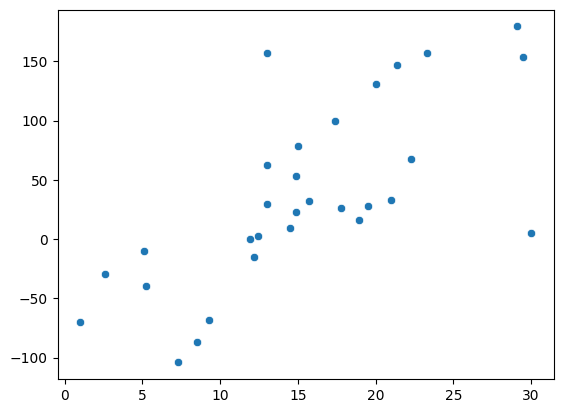

In [16]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

# --- CONFIGURATION ---
NUM_POINTS = 30
NOISE_LEVEL = 50  # Higher = harder to see the line (Market Volatility)
OUTLIER_STRENGTH = 90  # How far the trap points deviate

# 1. Generate the Base Market Data
# bias = intercept (c), noise = scatter
X, y, coef = make_regression(n_samples=NUM_POINTS, n_features=1, noise=NOISE_LEVEL, bias=50, coef=True, random_state=42)

# Flatten X for easier handling
X = X.flatten()

# Scale X to look like "Years" (e.g., Year 1 to Year 20)
# make_regression gives centered data, so we shift it to be positive
X_shifted = np.interp(X, (X.min(), X.max()), (1, NUM_POINTS))
X_final = np.round(X_shifted, 1) # Round to 1 decimal for clean Desmos entry

# 2. Inject the "Traps" (The Leverage Points)
# We skew the first and last points to trick the human eye
y[np.argmin(X_final)] += OUTLIER_STRENGTH  # Spike the start
y[np.argmax(X_final)] -= OUTLIER_STRENGTH  # Crash the end

# 3. Calculate the "Judge's Answer Key" (True Minimum MSE)
model = LinearRegression()
X_reshaped = X_final.reshape(-1, 1)
model.fit(X_reshaped, y)

best_m = model.coef_[0]
best_c = model.intercept_
min_mse = mean_squared_error(y, model.predict(X_reshaped))

# --- OUTPUT ---
sns.scatterplot(x=X_final, y=y)

print("x values (Year) | y values (Price)")
for xi, yi in zip(X_final, y):
    print(f"{xi:.1f}\t{yi:.2f}")

print("\n--- JUDGE'S ANSWER KEY ---")
print(f"True Best Slope (m): {best_m:.4f}")
print(f"True Best Intercept (c): {best_c:.4f}")
print(f"Minimum Possible MSE (Risk): {min_mse:.4f}")